In [1]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, desc, avg, sum, min, max

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

spark = (
    SparkSession.builder
    .appName("GlobalClimateVolatility-Notebook")
    .master("local[2]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.hadoop.fs.s3a.endpoint", "http://127.0.0.1:9000")
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config(
        "spark.hadoop.fs.s3a.aws.credentials.provider",
        "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark session started successfully.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/12 17:38:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session started successfully.


In [3]:
monthly_path = "s3a://climate-data/processed/monthly/2024/"
volatility_path = "s3a://climate-data/processed/volatility/2024/"

monthly_df = spark.read.parquet(monthly_path)
volatility_df = spark.read.parquet(volatility_path)

print("Monthly records:", monthly_df.count())
print("Daily records:", volatility_df.count())

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


Monthly records: 941
Daily records: 26545


In [4]:
print("MONTHLY SCHEMA")
monthly_df.printSchema()

print("\nVOLATILITY SCHEMA")
volatility_df.printSchema()

MONTHLY SCHEMA
root
 |-- STATION: integer (nullable = true)
 |-- NAME: string (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- TOTAL_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_DAYS: long (nullable = true)
 |-- HIGH_VOLATILITY_RATE: double (nullable = true)
 |-- AVG_VOLATILITY_SCORE: double (nullable = true)
 |-- MAX_VOLATILITY_SCORE: double (nullable = true)
 |-- AVG_TEMP_ANOMALY: double (nullable = true)
 |-- AVG_TEMP_VOLATILITY: double (nullable = true)
 |-- AVG_PRCP_VOLATILITY: double (nullable = true)
 |-- AVG_WIND_VOLATILITY: double (nullable = true)


VOLATILITY SCHEMA
root
 |-- STATION: integer (nullable = true)
 |-- DATE: date (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- ELEVATION: double (nullable = true)
 |-- NAME: string (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MO

In [5]:
print("MONTHLY SAMPLE")
monthly_df.show(5, truncate=False)

print("\nVOLATILITY SAMPLE")
volatility_df.show(5, truncate=False)

MONTHLY SAMPLE
+----------+-----------------+----------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+---------------------+--------------------+-------------------+
|STATION   |NAME             |LATITUDE  |LONGITUDE |YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY   |AVG_TEMP_VOLATILITY  |AVG_PRCP_VOLATILITY |AVG_WIND_VOLATILITY|
+----------+-----------------+----------+----------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+-------------------+---------------------+--------------------+-------------------+
|1122099999|KJAERSTAD, NO    |65.783997 |13.214914 |2024|8    |30        |0                   |0.0                 |-0.1569983177945337 |0.1813686216566901  |17.06              |-0.7573571106483068  |0.3513285259305029  |-0.7413909618584406|
|1089099999|HOYBU

26/08/12 17:40:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+----------+----------+----------+---------+----------------------+----+-----+---+----+----+----+----+----------+------------------+------------+----+------+-----+----+-----+----+----+-----------+-----------+-----------+---------------------+------------------------+------------------------+------------------------+-----------------+-----------------+-----------------+------------------+-------------------+-------------------+----------------+------------------+----------------------+-------------------------+-------------------------+-------------------------+------------------------+---------------+
|STATION   |DATE      |LATITUDE  |LONGITUDE |ELEVATION|NAME                  |YEAR|MONTH|DAY|WEEK|TEMP|MAX |MIN |TEMP_RANGE|TEMP_MEAN         |TEMP_ANOMALY|DEWP|SLP   |VISIB|WDSP|MXSPD|GUST|PRCP|TEMP_7D_STD|PRCP_7D_STD|WDSP_7D_STD|TEMP_ANOMALY_Z_GLOBAL|TEMP_VOLATILITY_Z_GLOBAL|PRCP_VOLATILITY_Z_GLOBAL|WIND_VOLATILITY_Z_GLOBAL|ta_m_s           |ta_s_s           |tv_m_s          

In [6]:
print("MONTHLY NULL COUNTS")

monthly_df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in monthly_df.columns
]).show(truncate=False)

MONTHLY NULL COUNTS
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|STATION|NAME|LATITUDE|LONGITUDE|YEAR|MONTH|TOTAL_DAYS|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|AVG_TEMP_ANOMALY|AVG_TEMP_VOLATILITY|AVG_PRCP_VOLATILITY|AVG_WIND_VOLATILITY|
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+--------------------+--------------------+----------------+-------------------+-------------------+-------------------+
|0      |0   |0       |0        |0   |0    |0         |0                   |0                   |0                   |0                   |0               |0                  |545                |48                 |
+-------+----+--------+---------+----+-----+----------+--------------------+--------------------+---------------

In [7]:
print("Total monthly records:", monthly_df.count())
print("Unique stations:", monthly_df.select("STATION").distinct().count())
print("Unique months:", monthly_df.select("MONTH").distinct().count())
print("Year:", monthly_df.select("YEAR").distinct().collect()[0][0])

Total monthly records: 941
Unique stations: 79
Unique months: 12
Year: 2024


In [8]:
overall_stats = monthly_df.select(
    avg("HIGH_VOLATILITY_RATE").alias("Average High-Volatility Rate"),
    min("HIGH_VOLATILITY_RATE").alias("Minimum High-Volatility Rate"),
    max("HIGH_VOLATILITY_RATE").alias("Maximum High-Volatility Rate"),
    avg("AVG_VOLATILITY_SCORE").alias("Average Volatility Score"),
    min("AVG_VOLATILITY_SCORE").alias("Minimum Volatility Score"),
    max("AVG_VOLATILITY_SCORE").alias("Maximum Volatility Score")
)

overall_stats.show()

+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|Average High-Volatility Rate|Minimum High-Volatility Rate|Maximum High-Volatility Rate|Average Volatility Score|Minimum Volatility Score|Maximum Volatility Score|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+
|        0.058643305171229634|                         0.0|                         1.0|    0.005237889774977...|     -0.7455924212880732|       1.269612837801155|
+----------------------------+----------------------------+----------------------------+------------------------+------------------------+------------------------+



In [9]:
top_events = (
    monthly_df
    .orderBy(desc("AVG_VOLATILITY_SCORE"))
    .select(
        "STATION",
        "NAME",
        "YEAR",
        "MONTH",
        "AVG_VOLATILITY_SCORE",
        "MAX_VOLATILITY_SCORE",
        "HIGH_VOLATILITY_DAYS",
        "HIGH_VOLATILITY_RATE"
    )
)

top_events.show(10, truncate=False)

+----------+---------------------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|STATION   |NAME                       |YEAR|MONTH|AVG_VOLATILITY_SCORE|MAX_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|HIGH_VOLATILITY_RATE|
+----------+---------------------------+----+-----+--------------------+--------------------+--------------------+--------------------+
|1088299999|ROROS, NO                  |2024|1    |1.269612837801155   |3.100936812707053   |21                  |0.6774193548387096  |
|1139099999|VAEROY HELIPORT, NO        |2024|3    |1.154936962037163   |1.2474210662821132  |3                   |1.0                 |
|1088299999|ROROS, NO                  |2024|2    |1.0047798235594994  |3.0097707865188283  |12                  |0.41379310344827586 |
|1011099999|KVITOYA, SV                |2024|1    |0.9885124230871749  |2.0983396195774544  |9                   |0.391304347826087   |
|1059099999|BANAK, NO                  |2024|1  

In [10]:
station_summary = (
    monthly_df
    .groupBy("STATION", "NAME")
    .agg(
        avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),
        sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS"),
        avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE")
    )
    .orderBy(desc("AVG_VOLATILITY_SCORE"))
)

station_summary.show(10, truncate=False)

+----------+---------------------+--------------------+--------------------+------------------------+
|STATION   |NAME                 |AVG_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|AVG_HIGH_VOLATILITY_RATE|
+----------+---------------------+--------------------+--------------------+------------------------+
|1139099999|VAEROY HELIPORT, NO  |0.18575478116699562 |15                  |0.14812875296746264     |
|1002099999|VERLEGENHUKEN, NO    |0.03799653191412387 |11                  |0.057368009670641255    |
|1015099999|HEKKINGEN FYR, NO    |0.03655189749329329 |9                   |0.030534877309070858    |
|1117099999|TJOTTA, NO           |0.02565603175008199 |18                  |0.05767408548276179     |
|1006099999|EDGEOYA, NO          |0.02248956850240137 |19                  |0.08068783068783068     |
|1016099999|KONGSOYA, NO         |0.019514680008213884|27                  |0.09672117413683812     |
|1068099999|HONNINGSVAG VALAN, NO|0.017512116595411253|23                  |0.0737

/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


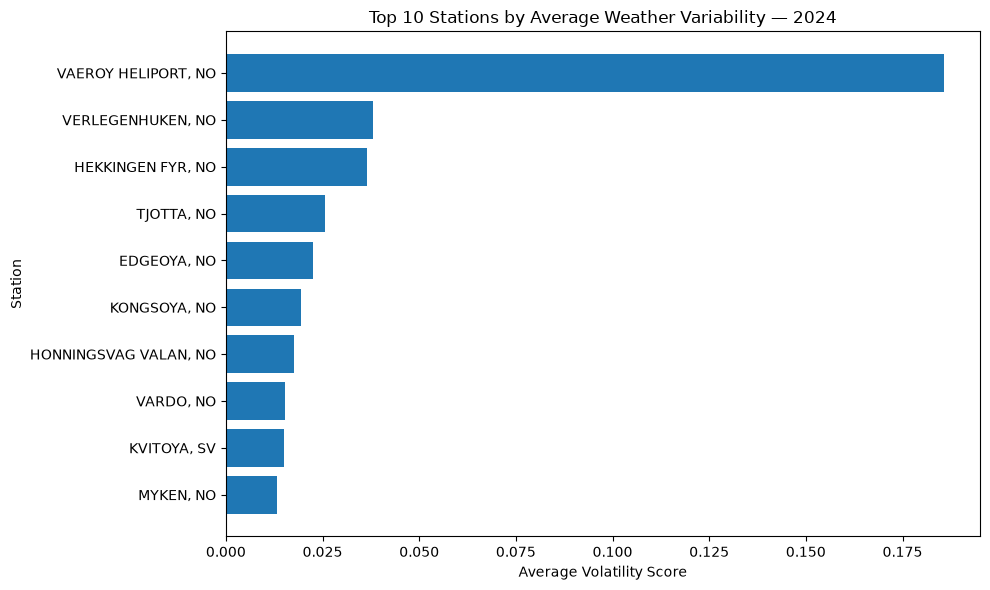

In [18]:
top10_station_pd = (
    station_summary
    .orderBy(desc("AVG_VOLATILITY_SCORE"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_station_pd["NAME"],
    top10_station_pd["AVG_VOLATILITY_SCORE"]
)
plt.xlabel("Average Volatility Score")
plt.ylabel("Station")
plt.title("Top 10 Stations by Average Weather Variability — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


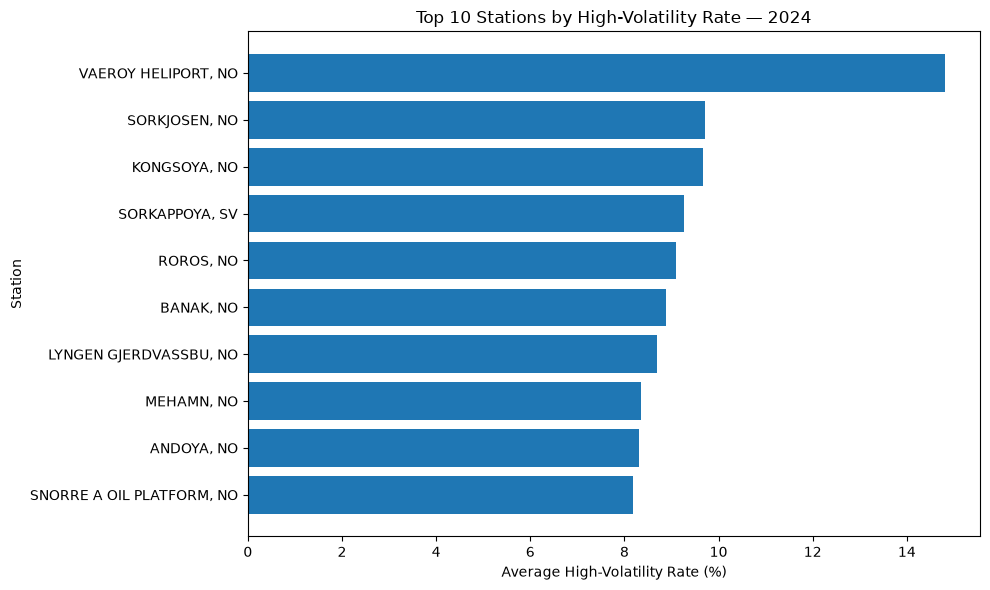

In [19]:
top10_rate_pd = (
    station_summary
    .orderBy(desc("AVG_HIGH_VOLATILITY_RATE"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_rate_pd["NAME"],
    top10_rate_pd["AVG_HIGH_VOLATILITY_RATE"] * 100
)
plt.xlabel("Average High-Volatility Rate (%)")
plt.ylabel("Station")
plt.title("Top 10 Stations by High-Volatility Rate — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
monthly_pattern = (
    monthly_df
    .groupBy("MONTH")
    .agg(
        avg("HIGH_VOLATILITY_RATE").alias("AVG_HIGH_VOLATILITY_RATE"),
        avg("AVG_VOLATILITY_SCORE").alias("AVG_VOLATILITY_SCORE"),
        sum("HIGH_VOLATILITY_DAYS").alias("HIGH_VOLATILITY_DAYS")
    )
    .orderBy("MONTH")
)

monthly_pattern.show(12)

+-----+------------------------+--------------------+--------------------+
|MONTH|AVG_HIGH_VOLATILITY_RATE|AVG_VOLATILITY_SCORE|HIGH_VOLATILITY_DAYS|
+-----+------------------------+--------------------+--------------------+
|    1|     0.18923192132545902| 0.47431066129506844|                 448|
|    2|     0.14725952000162995|  0.3252183126010946|                 326|
|    3|     0.06275153533925462|-0.01535772945183...|                  86|
|    4|    0.030623767219105914| -0.1793401795592784|                  53|
|    5|     0.03224145557721326|-0.22127998342550667|                  74|
|    6|    0.009599712760632298| -0.2057307466797542|                  22|
|    7|     0.03814364765351093|-0.05870891502861558|                  88|
|    8|     0.01033179424359498|-0.02566982008479...|                  24|
|    9|     0.01729957805907173| -0.0494945176132663|                  41|
|   10|    0.006294330263297189| -0.3129211299858214|                  15|
|   11|     0.03018102151

In [14]:
seasonal_pd = monthly_pattern.toPandas()
seasonal_pd

/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/gururaman14/diss-venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,MONTH,AVG_HIGH_VOLATILITY_RATE,AVG_VOLATILITY_SCORE,HIGH_VOLATILITY_DAYS
0,1,0.189232,0.474311,448
1,2,0.147260,0.325218,326
2,3,0.062752,-0.015358,86
3,4,0.030624,-0.179340,53
4,5,0.032241,-0.221280,74
5,6,0.009600,-0.205731,22
6,7,0.038144,-0.058709,88
7,8,0.010332,-0.025670,24
8,9,0.017300,-0.049495,41
9,10,0.006294,-0.312921,15


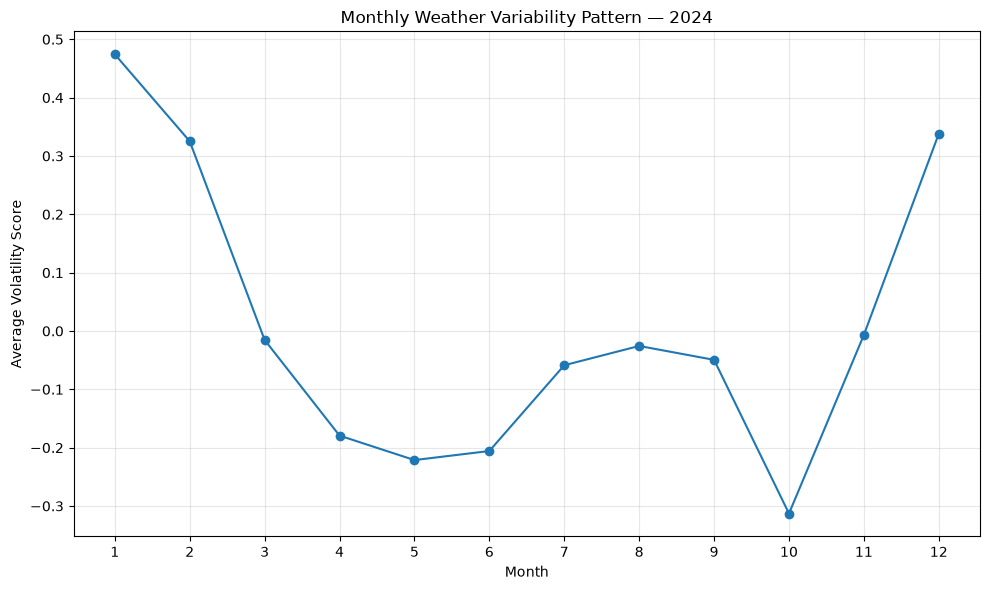

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(
    seasonal_pd["MONTH"],
    seasonal_pd["AVG_VOLATILITY_SCORE"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Average Volatility Score")
plt.title("Monthly Weather Variability Pattern — 2024")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

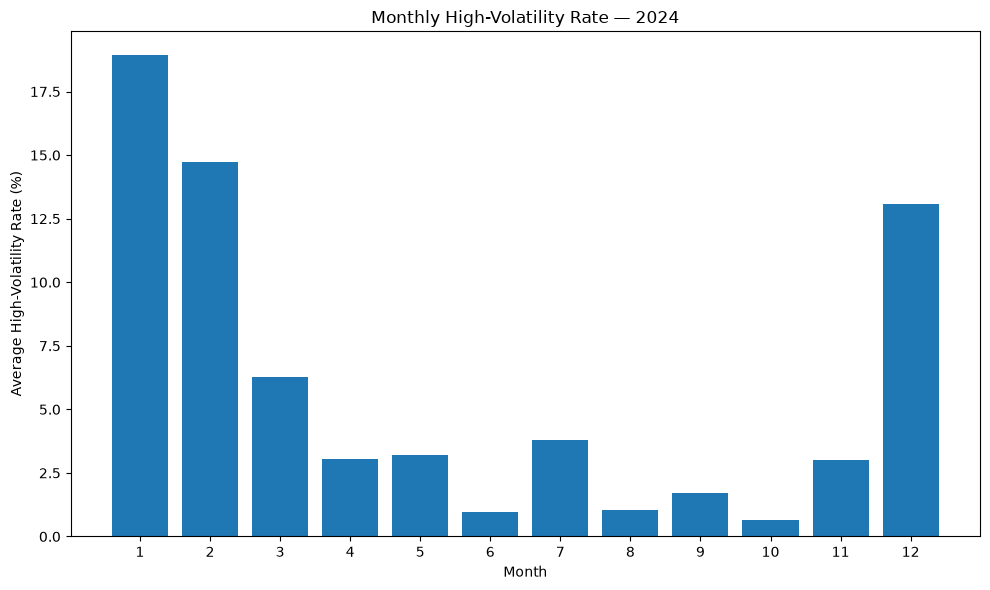

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(
    seasonal_pd["MONTH"],
    seasonal_pd["AVG_HIGH_VOLATILITY_RATE"] * 100
)
plt.xlabel("Month")
plt.ylabel("Average High-Volatility Rate (%)")
plt.title("Monthly High-Volatility Rate — 2024")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [17]:
daily_records = volatility_df.count()
station_count = monthly_df.select("STATION").distinct().count()
monthly_records = monthly_df.count()
qualified_station_months = monthly_df.filter(
    col("TOTAL_DAYS") >= 20
).count()
month_count = monthly_df.select("MONTH").distinct().count()
high_volatility_days = volatility_df.filter(
    col("HIGH_VOLATILITY") == 1
).count()

print("=== FINAL SUMMARY ===")
print("Daily records:", daily_records)
print("Stations:", station_count)
print("Monthly records:", monthly_records)
print("Qualified station-months:", qualified_station_months)
print("Months:", month_count)
print("High-volatility days:", high_volatility_days)

=== FINAL SUMMARY ===
Daily records: 26545
Stations: 79
Monthly records: 941
Qualified station-months: 903
Months: 12
High-volatility days: 1537
